# Análisis de correlaciones entre características
Correlaciones de Pearson entre features y con la temperatura.
Permite identificar features redundantes y descartar las que no aportan información.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

CSV_PATH = Path("dataset_features_temperatura.csv")

In [2]:
df = pd.read_csv(CSV_PATH)

META_COLS = {
    "sample_uid", "sample_id", "tx_path", "rx_path",
    "tx_path_rel_to_bbdd_parent", "rx_path_rel_to_bbdd_parent",
    "split", "temperature_folder",
    "N_subcarriers", "M_symbols", "num_valid", "valid_ratio",
}
CONSTANT_COLS = [c for c in df.columns if c not in META_COLS
                 and c != "temperature" and df[c].std() == 0]
print(f"Columnas constantes (se descartan): {CONSTANT_COLS}")

FEAT_COLS = [c for c in df.columns
             if c not in META_COLS
             and c != "temperature"
             and c not in CONSTANT_COLS]
print(f"Features disponibles: {len(FEAT_COLS)}")

df_train = df[df["split"] == "train"].copy()
print(f"Muestras train: {len(df_train)}")

Columnas constantes (se descartan): ['phase_jump_m_count', 'phase_jump_m_ratio', 'phase_jump_k_count', 'phase_jump_k_ratio']
Features disponibles: 58
Muestras train: 22566


In [3]:
X = df_train[FEAT_COLS]
y = df_train["temperature"]

corr_with_temp = X.corrwith(y).sort_values(key=abs, ascending=False)
print("Top 20 features más correladas con temperatura:")
print(corr_with_temp.head(20).to_string())
print()
print("Bottom 10 features menos correladas:")
print(corr_with_temp.tail(10).to_string())

Top 20 features más correladas con temperatura:
mag_min                    -0.361580
svd_sigma_2                 0.357587
svd_sigma_ratio            -0.302275
mag_var                     0.295507
phase_jump_m_max_abs        0.286711
mag_dynamic_range_db        0.282221
mag_energy_total            0.277376
pdp_total_energy            0.277376
phase_jump_k_max_abs        0.275900
svd_spectral_flatness       0.273643
dH_dt_max                   0.226457
pdp_los_peak_power          0.223583
mag_dynamic_range_linear    0.219375
mag_max                     0.196543
dH_dt_mean                  0.183503
doppler_variance_energy     0.183126
mag_percentile_99           0.175517
mag_percentile_95           0.164547
mag_entropy                 0.162281
mag_entropy_normalized      0.162281

Bottom 10 features menos correladas:
phase_unwrap_k_mean          0.035241
phase_circular_variance      0.035110
phase_coherence             -0.035110
phase_unwrap_m_var           0.034197
phase_unwrap_k_slope_m

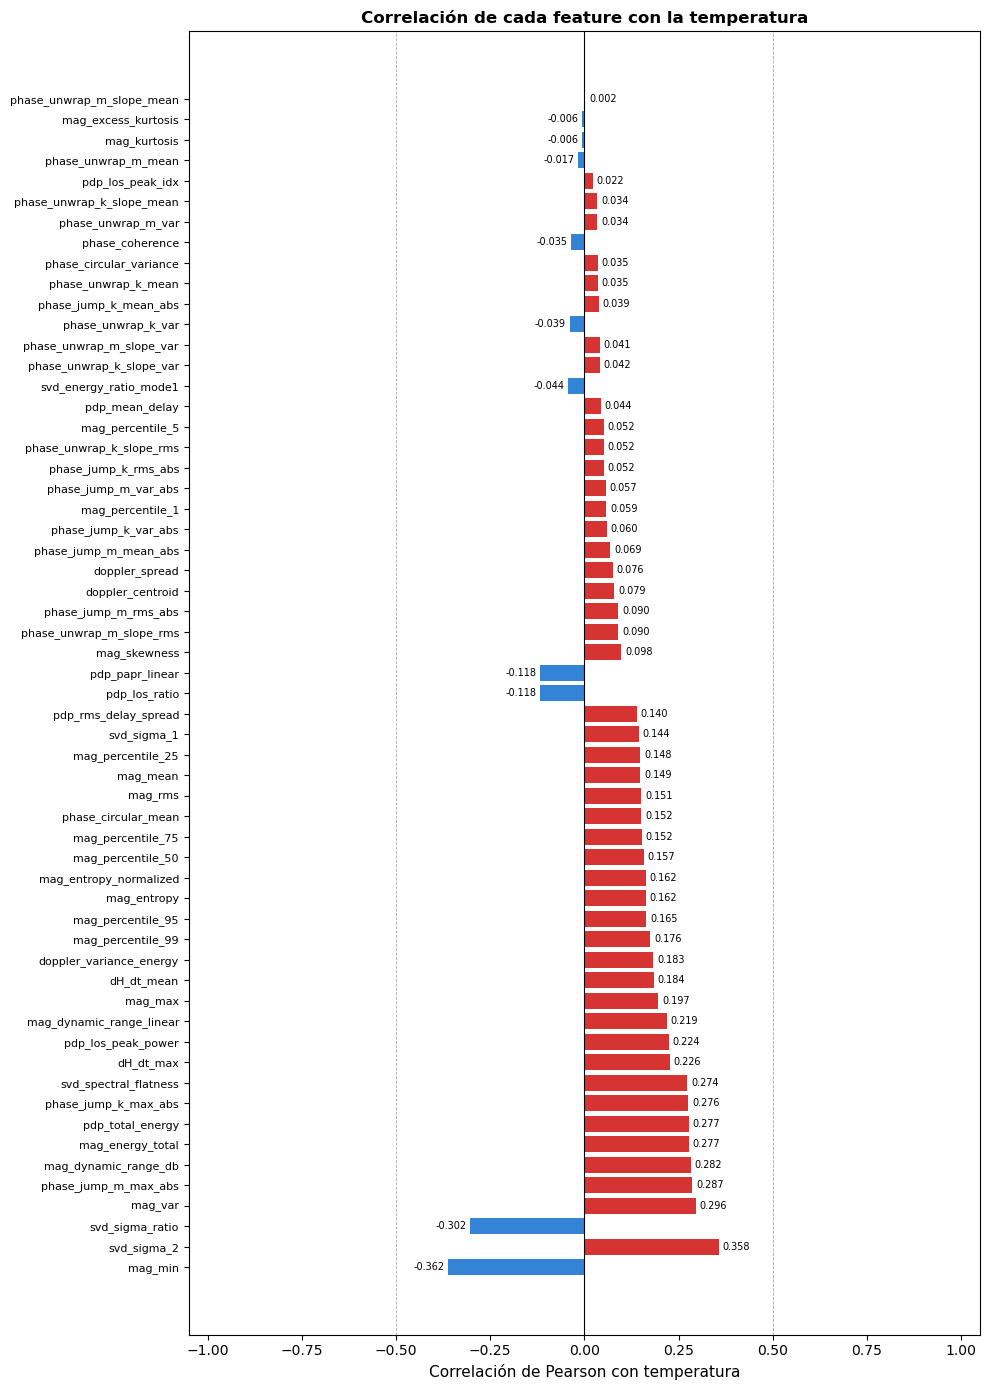

In [4]:
fig, ax = plt.subplots(figsize=(10, 14))
colors = ["#CC0000" if v > 0 else "#0066CC" for v in corr_with_temp.values]
bars = ax.barh(corr_with_temp.index, corr_with_temp.values, color=colors, alpha=0.8)
ax.axvline(0,    color="black", linewidth=0.8)
ax.axvline( 0.5, color="gray",  linewidth=0.6, linestyle="--", alpha=0.7)
ax.axvline(-0.5, color="gray",  linewidth=0.6, linestyle="--", alpha=0.7)
for bar, val in zip(bars, corr_with_temp.values):
    x_pos = val + 0.01 if val >= 0 else val - 0.01
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", ha="left" if val>=0 else "right", fontsize=7)
ax.set_xlabel("Correlación de Pearson con temperatura", fontsize=11)
ax.set_title("Correlación de cada feature con la temperatura", fontsize=12, fontweight="bold")
ax.tick_params(axis="y", labelsize=8)
ax.set_xlim(-1.05, 1.05)
plt.tight_layout()
plt.savefig("corr_features_vs_temperatura.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
REDUNDANCY_THRESHOLD = 0.95
corr_matrix = X.corr(method="pearson")

high_corr_pairs = []
for i in range(len(FEAT_COLS)):
    for j in range(i+1, len(FEAT_COLS)):
        r = corr_matrix.iloc[i, j]
        if abs(r) >= REDUNDANCY_THRESHOLD:
            high_corr_pairs.append((FEAT_COLS[i], FEAT_COLS[j], r))
high_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

print(f"Pares con |r| >= {REDUNDANCY_THRESHOLD}: {len(high_corr_pairs)}")
for f1, f2, r in high_corr_pairs:
    print(f"  {f1:45s}  {f2:45s}  r={r:.4f}")

Pares con |r| >= 0.95: 280
  phase_circular_variance                        phase_coherence                                r=-1.0000
  mag_energy_total                               pdp_total_energy                               r=1.0000
  mag_kurtosis                                   mag_excess_kurtosis                            r=1.0000
  phase_unwrap_m_slope_rms                       phase_jump_m_rms_abs                           r=1.0000
  phase_unwrap_k_slope_rms                       phase_jump_k_rms_abs                           r=1.0000
  pdp_papr_linear                                pdp_los_ratio                                  r=1.0000
  mag_entropy                                    mag_entropy_normalized                         r=1.0000
  phase_unwrap_m_slope_var                       phase_unwrap_k_slope_var                       r=1.0000
  phase_unwrap_k_slope_var                       phase_jump_k_mean_abs                          r=1.0000
  phase_unwrap_k_slope_var 

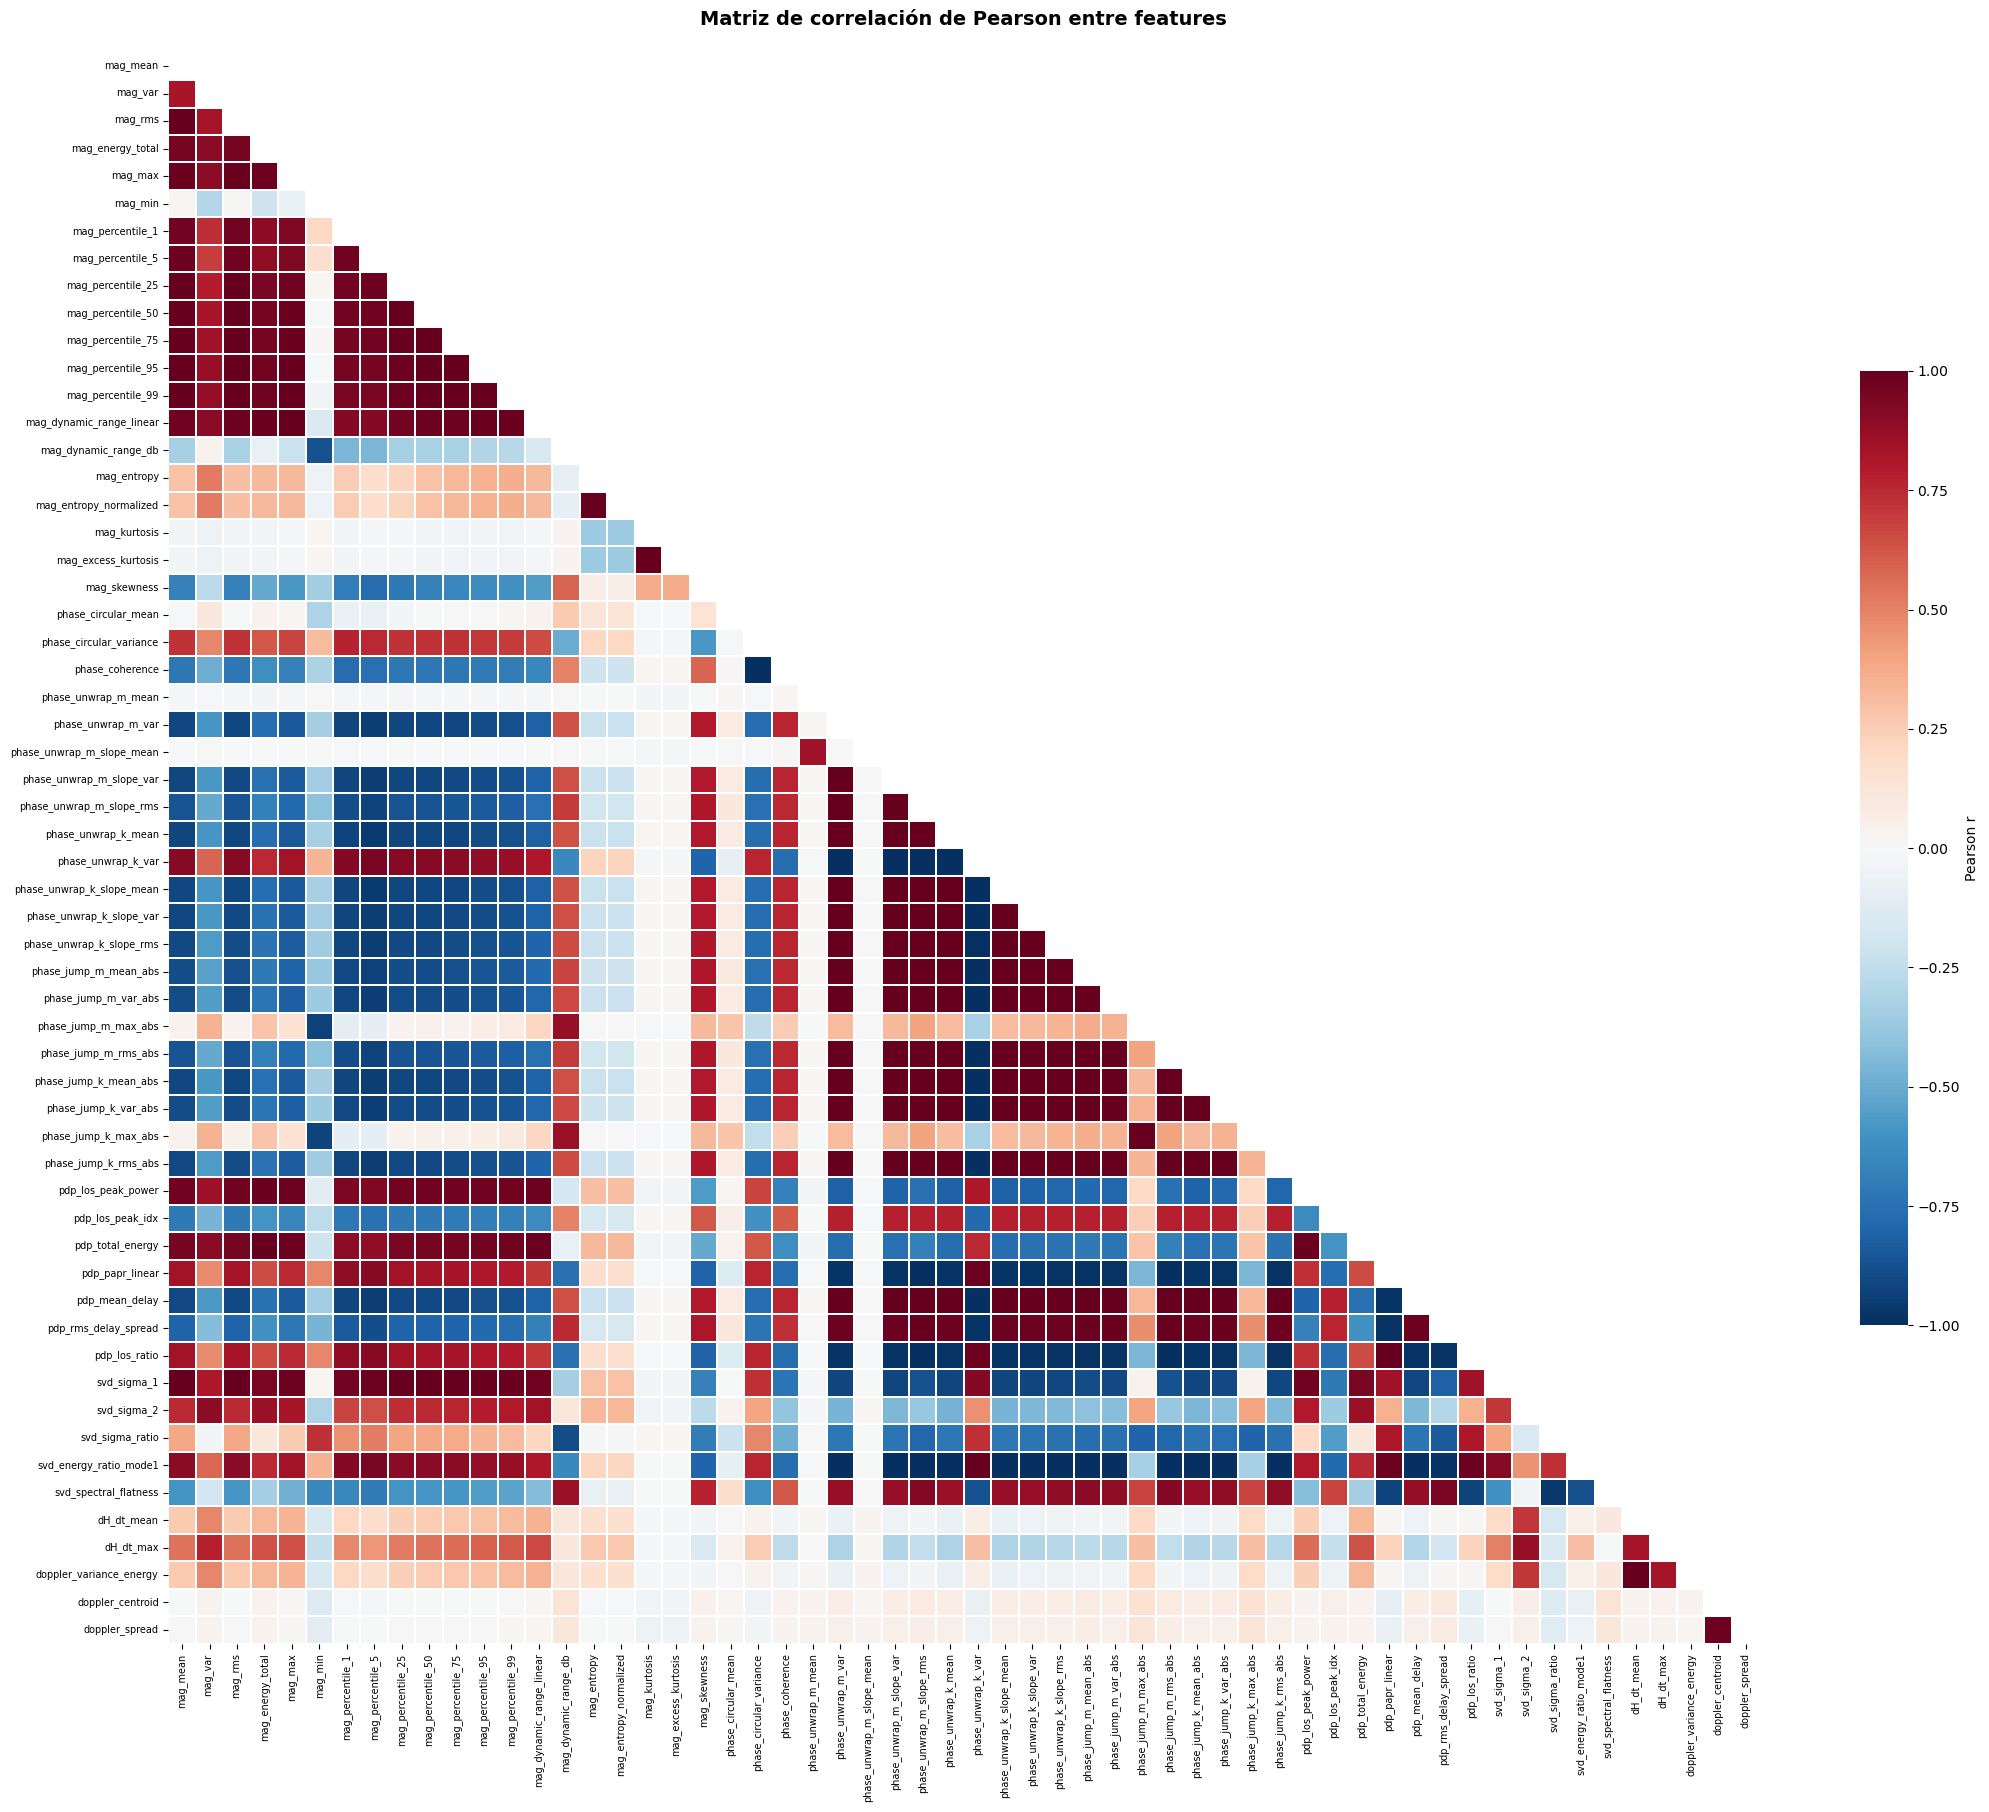

In [6]:
fig, ax = plt.subplots(figsize=(22, 18))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr_matrix, mask=mask, cmap="RdBu_r", vmin=-1, vmax=1,
            center=0, square=True, linewidths=0.3, annot=False,
            cbar_kws={"shrink": 0.6, "label": "Pearson r"}, ax=ax)
ax.set_title("Matriz de correlación de Pearson entre features", fontsize=14, fontweight="bold", pad=20)
ax.tick_params(axis="x", labelsize=7, rotation=90)
ax.tick_params(axis="y", labelsize=7, rotation=0)
plt.tight_layout()
plt.savefig("heatmap_correlaciones.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
to_drop = set()
LOW_CORR_THRESHOLD = 0.05
for f1, f2, r in high_corr_pairs:
    if f1 in to_drop or f2 in to_drop:
        continue
    r1 = abs(corr_with_temp.get(f1, 0))
    r2 = abs(corr_with_temp.get(f2, 0))
    to_drop.add(f2 if r1 >= r2 else f1)

low_corr_feats = [f for f in FEAT_COLS if abs(corr_with_temp.get(f, 0)) < LOW_CORR_THRESHOLD]
all_to_drop = to_drop | set(low_corr_feats) | set(CONSTANT_COLS)
FEAT_SELECTED = [f for f in FEAT_COLS if f not in all_to_drop]

print(f"Features seleccionadas: {len(FEAT_COLS)} -> {len(FEAT_SELECTED)}")
for f in FEAT_SELECTED:
    print(f"  {f:50s}  r={corr_with_temp.get(f,0):.4f}")

Features seleccionadas: 58 -> 15
  mag_var                                             r=0.2955
  mag_energy_total                                    r=0.2774
  mag_min                                             r=-0.3616
  mag_percentile_1                                    r=0.0587
  mag_dynamic_range_db                                r=0.2822
  mag_entropy                                         r=0.1623
  mag_skewness                                        r=0.0985
  phase_circular_mean                                 r=0.1516
  phase_jump_m_max_abs                                r=0.2867
  pdp_rms_delay_spread                                r=0.1396
  svd_sigma_2                                         r=0.3576
  svd_sigma_ratio                                     r=-0.3023
  dH_dt_mean                                          r=0.1835
  dH_dt_max                                           r=0.2265
  doppler_centroid                                    r=0.0790


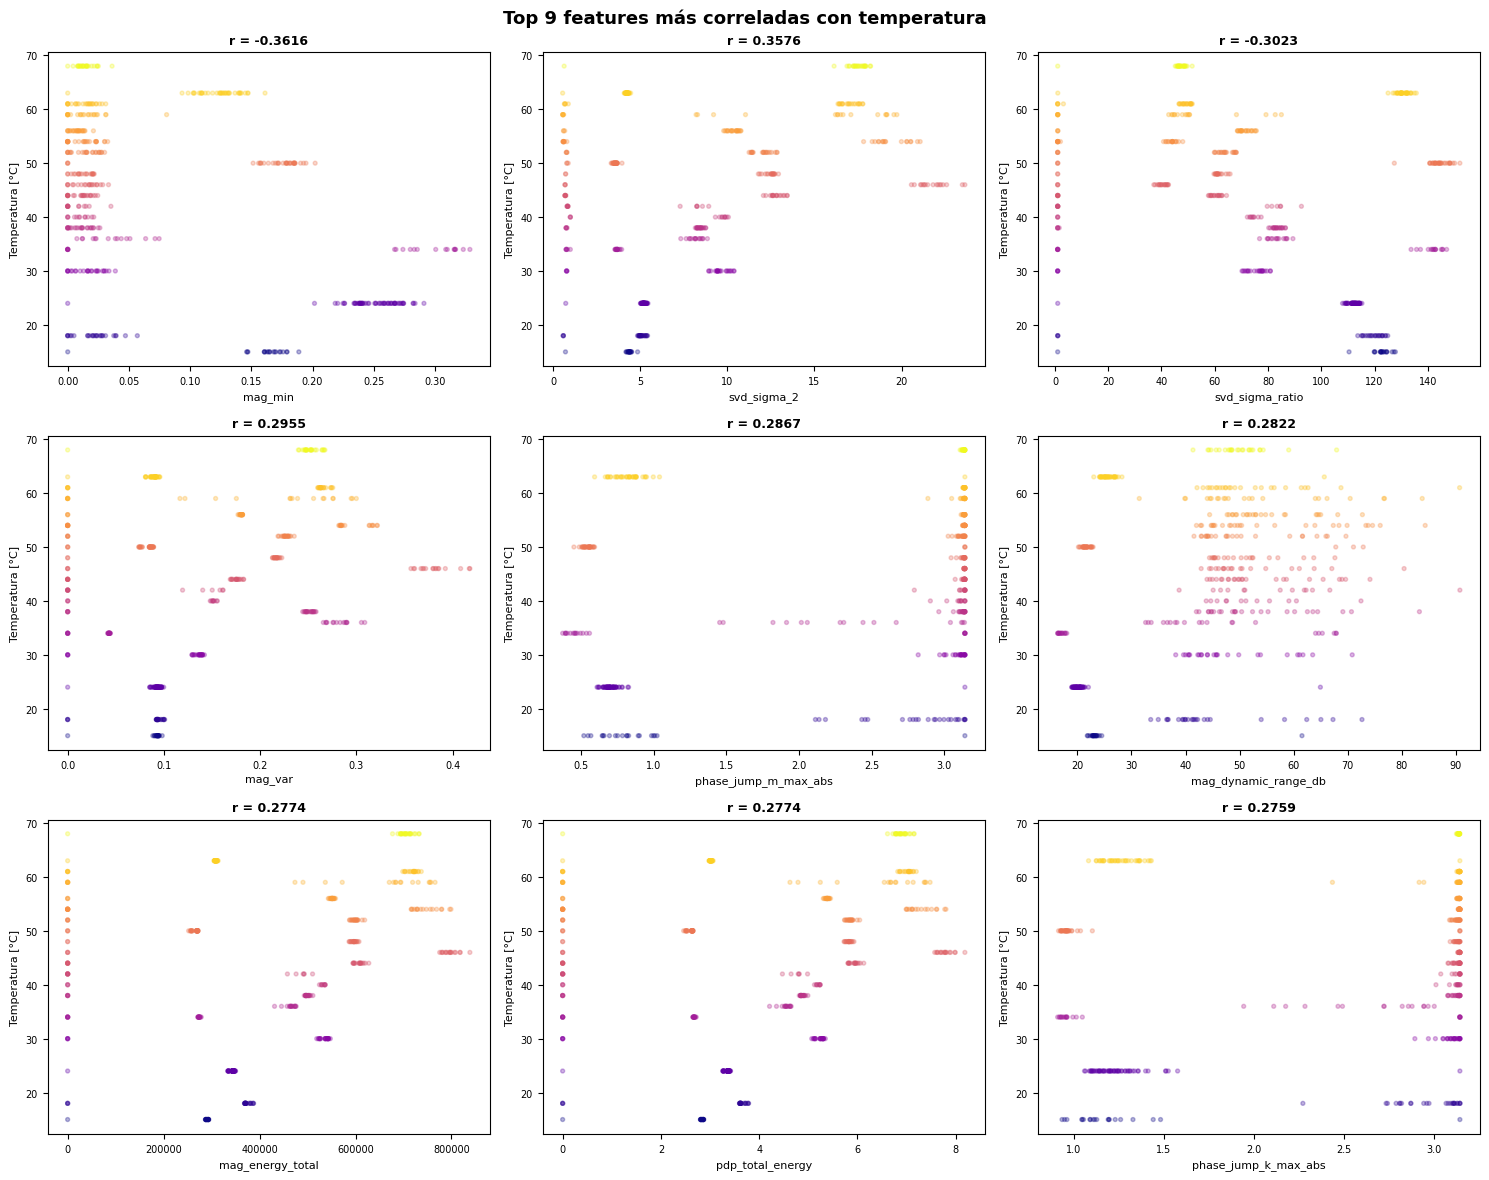

Guardado: features_seleccionadas.json (15 features)


In [8]:
top_feats = corr_with_temp.abs().nlargest(9).index.tolist()
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
sample = df_train.sample(min(500, len(df_train)), random_state=42)
for i, feat in enumerate(top_feats):
    ax = axes[i]
    ax.scatter(sample[feat], sample["temperature"],
               alpha=0.3, s=8, c=sample["temperature"], cmap="plasma")
    ax.set_xlabel(feat, fontsize=8)
    ax.set_ylabel("Temperatura [°C]", fontsize=8)
    ax.set_title(f"r = {corr_with_temp[feat]:.4f}", fontsize=9, fontweight="bold")
    ax.tick_params(labelsize=7)
plt.suptitle("Top 9 features más correladas con temperatura", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("scatter_top_features.png", dpi=150, bbox_inches="tight")
plt.show()

with open("features_seleccionadas.json", "w") as f:
    json.dump(FEAT_SELECTED, f, indent=2)
print(f"Guardado: features_seleccionadas.json ({len(FEAT_SELECTED)} features)")